In [6]:
!rm -rf r-server-loan-credit-risk   # remove if multiple nested copies exist
!git clone https://github.com/microsoft/r-server-loan-credit-risk.git
%cd r-server-loan-credit-risk


Cloning into 'r-server-loan-credit-risk'...
remote: Enumerating objects: 773, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 773 (delta 0), reused 0 (delta 0), pack-reused 769 (from 1)
Receiving objects: 100% (773/773), 88.29 MiB | 27.12 MiB/s, done.
Resolving deltas: 100% (446/446), done.
/content/r-server-loan-credit-risk/r-server-loan-credit-risk/r-server-loan-credit-risk/r-server-loan-credit-risk/r-server-loan-credit-risk/r-server-loan-credit-risk


In [7]:
!ls Data | head


Borrower_Prod.txt
Borrower.txt
Loan_Prod.txt
Loan.txt


In [14]:
borrower = pd.read_csv("Data/Borrower.txt", sep="\t")

print("Borrower shape:", borrower.shape)
borrower.head()


Borrower shape: (100000, 17)


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,6,14301,49.02,0,19,10,0
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,4,18262,72.40,1,0,0,0
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,5,10799,66.27,0,1,1,0
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,3,15272,61.05,1,0,0,3
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,10,19316,56.39,2,14,7,1


In [35]:
# ===============================
# 1. Load and Inspect Data
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

borrower = pd.read_csv("Data/Borrower.txt", sep="\t")
print("Shape:", borrower.shape)
print(borrower.head())
print(borrower.info())


Shape: (100000, 17)
   memberId residentialState yearsEmployment homeOwnership  annualIncome  \
0   2305095               NM       10+ years          rent         56471   
1   2610493               WA       2-5 years          rent         55038   
2   2491679               MS        < 1 year          rent         56610   
3   2092798               TX       6-9 years           own         54887   
4   2633077               MA       2-5 years          rent         53522   

   incomeVerified  dtiRatio  lengthCreditHistory  numTotalCreditLines  \
0               1     16.80                    6                   11   
1               0     19.99                   22                    8   
2               1     14.33                    5                    8   
3               1     14.80                   12                   14   
4               1     10.14                    4                   21   

   numOpenCreditLines  numOpenCreditLines1Year  revolvingBalance  \
0               

In [36]:
# ===============================
# 2. Cleaning
# ===============================

# Drop rows with missing target
df = borrower.copy()

# Let's define target = incomeVerified (0 = not verified, 1 = verified)
target = "incomeVerified"
X = df.drop(columns=[target, "memberId"])   # remove IDs
y = df[target]

# Separate numeric and categorical features
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['annualIncome', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon']
Categorical: ['residentialState', 'yearsEmployment', 'homeOwnership']


In [37]:
# ===============================
# 3. Preprocessing Pipeline
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [38]:
# ===============================
# 4. Train Model
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6279
           1       0.69      1.00      0.81     13721

    accuracy                           0.69     20000
   macro avg       0.34      0.50      0.41     20000
weighted avg       0.47      0.69      0.56     20000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


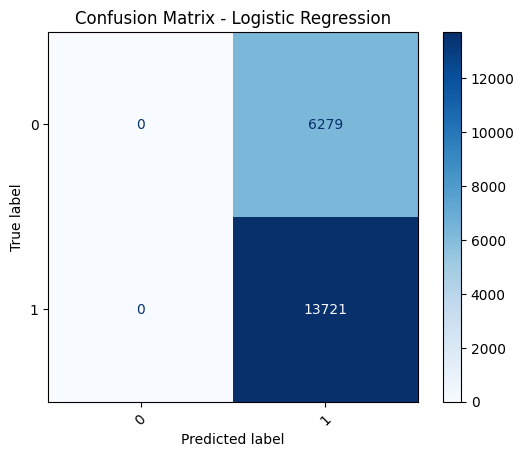

In [39]:
# ===============================
# 5. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


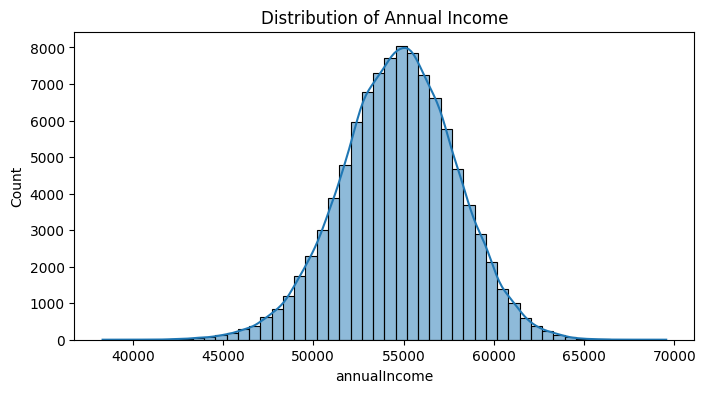

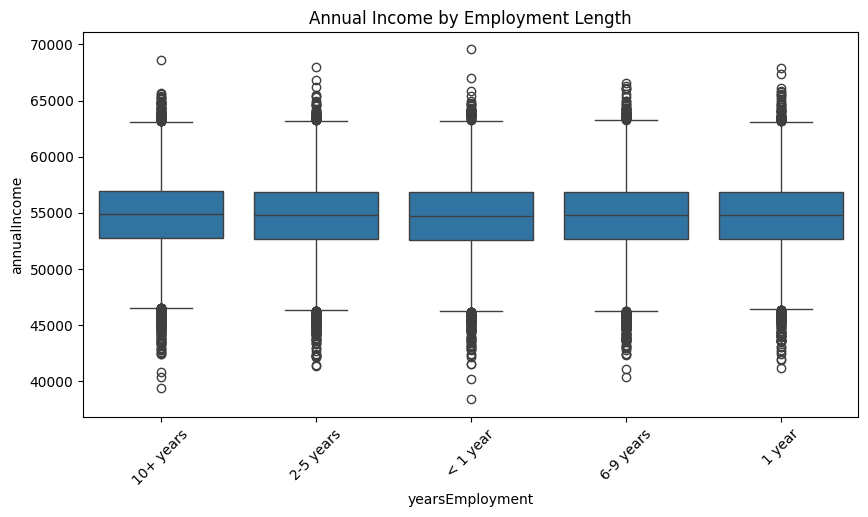

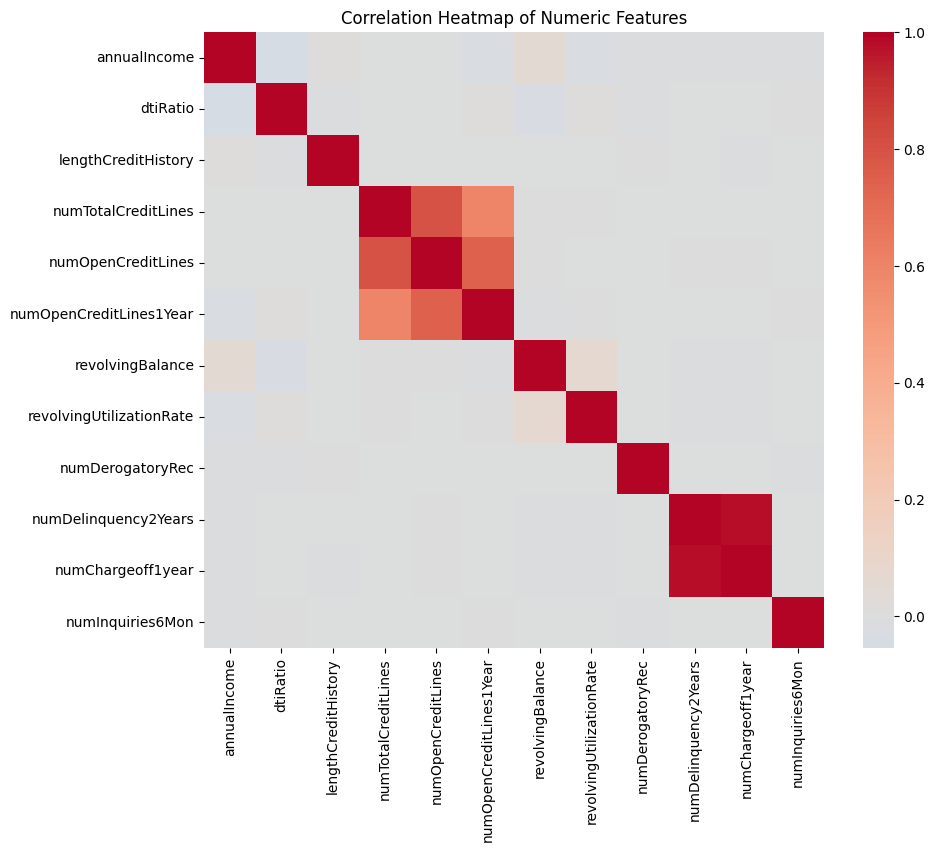

In [40]:
# ===============================
# 6. Visualizations
# ===============================

# Distribution of Annual Income
plt.figure(figsize=(8,4))
sns.histplot(df["annualIncome"], bins=50, kde=True)
plt.title("Distribution of Annual Income")
plt.show()

# Employment Length vs Annual Income
plt.figure(figsize=(10,5))
sns.boxplot(x="yearsEmployment", y="annualIncome", data=df)
plt.xticks(rotation=45)
plt.title("Annual Income by Employment Length")
plt.show()

# Correlation Heatmap (numerical only)
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [41]:
# ===============================
# 1. Load and Inspect Data -Loan.txt
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loan = pd.read_csv("Data/Loan.txt", sep="\t")
print("Shape:", loan.shape)
print(loan.head())
print(loan.info())


Shape: (100000, 11)
    loanId  memberId        date            purpose  isJointApplication  \
0  1888978   2305095  12/10/2014  debtconsolidation                 0.0   
1  1299695   2610493   9/15/2014  debtconsolidation                 0.0   
2  1875016   2491679   9/11/2014  debtconsolidation                 0.0   
3  1440478   2092798   4/22/2016    homeimprovement                 0.0   
4  1124634   2633077    2/3/2016  debtconsolidation                 0.0   

   loanAmount       term  interestRate  monthlyPayment grade loanStatus  
0     25190.0  60 months          6.25             490    E3    Current  
1     21189.0  60 months         10.49             455    B3    Current  
2     29908.0  60 months          9.11             622    B2    Current  
3     13053.0  48 months         11.89             343    B3    Current  
4     24613.0  60 months         15.13             587    A3    Current  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data col

In [42]:
# ===============================
# 2. Cleaning
# ===============================

# Drop rows with missing target
df = loan.copy()

# Define target = loanStatus (e.g., "Default" vs "Fully Paid")
target = "loanStatus"
X = df.drop(columns=[target, "loanId"])   # remove IDs
y = df[target]

# Separate numeric and categorical features
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['memberId', 'isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment']
Categorical: ['date', 'purpose', 'term', 'grade']


In [43]:
# ===============================
# 3. Preprocessing Pipeline
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [44]:
# ===============================
# 4. Train Model
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Current       0.92      0.99      0.95     17999
     Default       0.66      0.21      0.32      2001

    accuracy                           0.91     20000
   macro avg       0.79      0.60      0.63     20000
weighted avg       0.89      0.91      0.89     20000



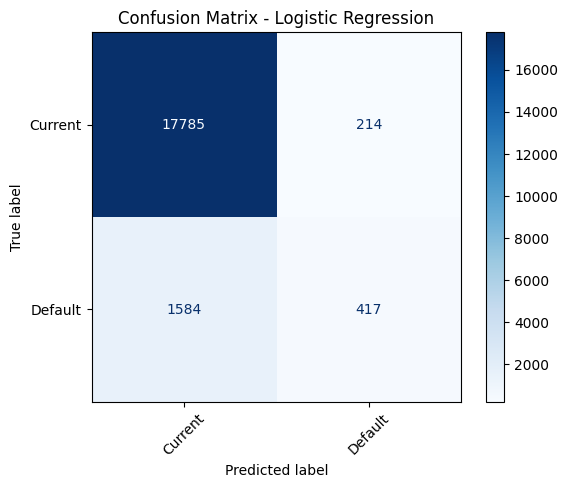

In [45]:
# ===============================
# 5. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


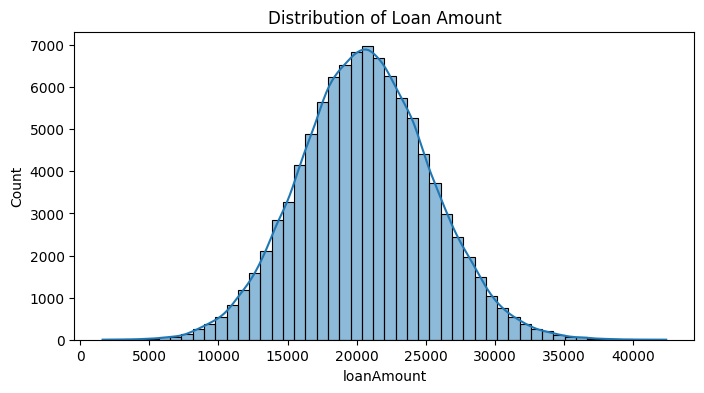

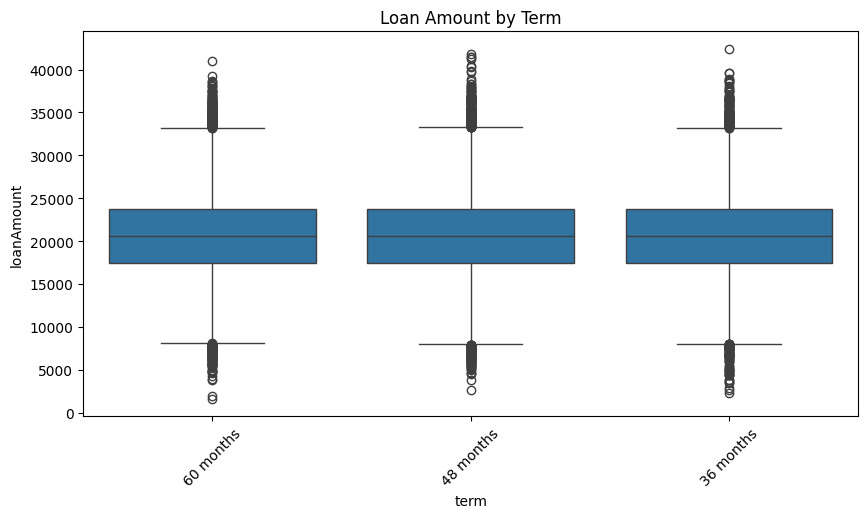

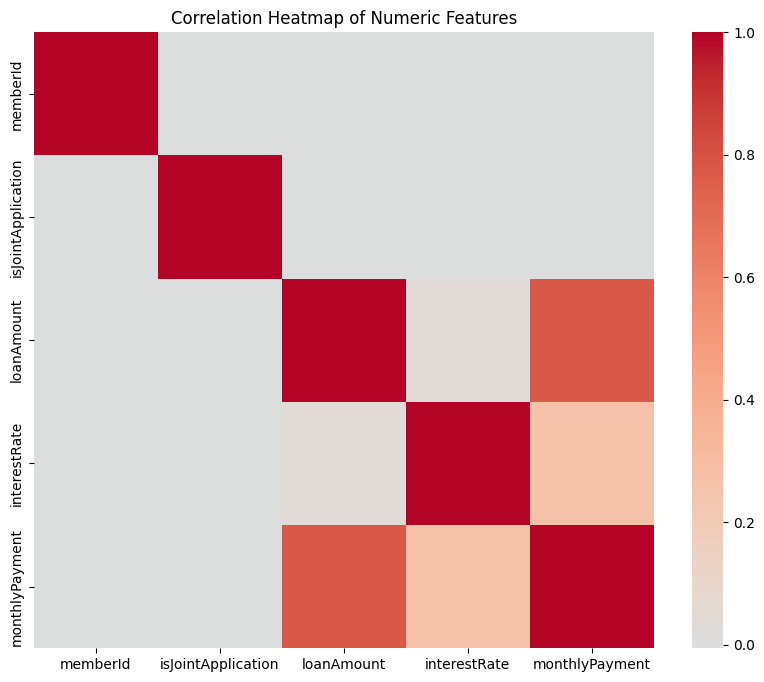

In [46]:
# ===============================
# 6. Visualizations
# ===============================

# Distribution of Loan Amount
plt.figure(figsize=(8,4))
sns.histplot(df["loanAmount"], bins=50, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

# Term vs Loan Amount
plt.figure(figsize=(10,5))
sns.boxplot(x="term", y="loanAmount", data=df)
plt.xticks(rotation=45)
plt.title("Loan Amount by Term")
plt.show()

# Correlation Heatmap (numerical only)
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [47]:
# ===============================
# 1. Load and Inspect Production Borrower Data
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

borrower_prod = pd.read_csv("Data/Borrower_Prod.txt", sep="\t")
print("Shape:", borrower_prod.shape)
print(borrower_prod.head())
print(borrower_prod.info())


Shape: (22, 17)
   memberId residentialState yearsEmployment homeOwnership  annualIncome  \
0  16334480               IL       6-9 years      mortgage         50975   
1  16334481               TN       2-5 years           own         51887   
2  16334482               PA       10+ years      mortgage         53254   
3  16334483               TX          1 year           own         59643   
4  16334484               CA        < 1 year      mortgage         60630   

   incomeVerified  dtiRatio  lengthCreditHistory  numTotalCreditLines  \
0               0     17.71                    1                   11   
1               1     23.84                    5                   19   
2               1     22.53                    2                   22   
3               1     15.26                    6                   13   
4               1      9.67                    4                   16   

   numOpenCreditLines  numOpenCreditLines1Year  revolvingBalance  \
0                   

In [48]:
# ===============================
# 2. Cleaning & Target
# ===============================

df = borrower_prod.copy()

# Define target (simulate or actual, e.g., incomeVerified)
target = "incomeVerified"
X = df.drop(columns=[target, "memberId"])
y = df[target]

# Separate numeric & categorical features
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['annualIncome', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon']
Categorical: ['residentialState', 'yearsEmployment', 'homeOwnership']


In [49]:
# ===============================
# 3. Preprocessing Pipeline
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


In [50]:
# ===============================
# 4. Train Model
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.80      1.00      0.89         4

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


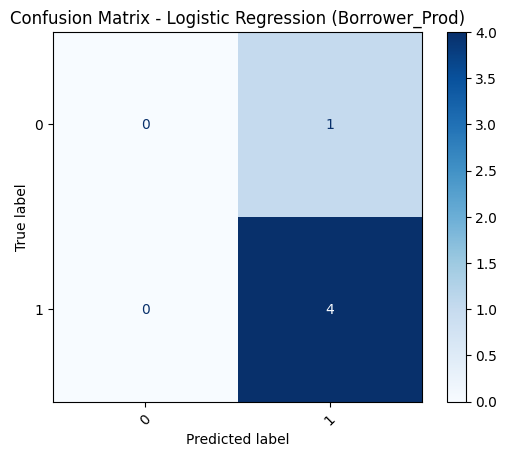

In [51]:
# ===============================
# 5. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression (Borrower_Prod)")
plt.show()


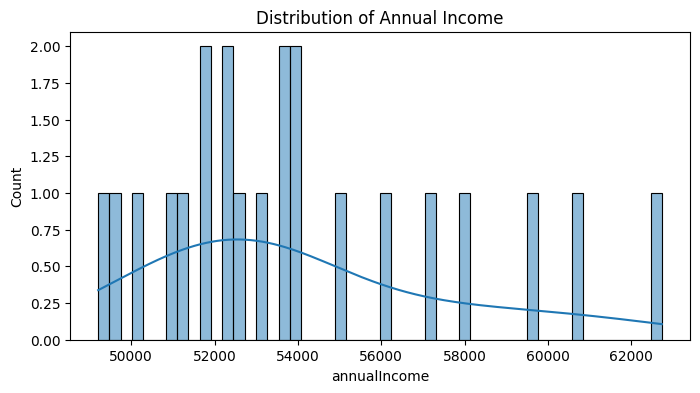

In [52]:
# ===============================
# 6. Visualizations
# ===============================
plt.figure(figsize=(8,4))
sns.histplot(df["annualIncome"], bins=50, kde=True)
plt.title("Distribution of Annual Income")
plt.show()


In [53]:
# ===============================
# 1. Load Production Loan Data
# ===============================
loan_prod = pd.read_csv("Data/Loan_Prod.txt", sep="\t")
print("Shape:", loan_prod.shape)
print(loan_prod.head())
print(loan_prod.info())


Shape: (22, 11)
     loanId  memberId      date            purpose  isJointApplication  \
0  10000000  16334480  7/2/2016  debtconsolidation                   0   
1  10000001  16334481  7/3/2016  debtconsolidation                   0   
2  10000002  16334482  7/4/2016  debtconsolidation                   0   
3  10000003  16334483  7/5/2016  debtconsolidation                   0   
4  10000004  16334484  7/6/2016  debtconsolidation                   0   

   loanAmount       term  interestRate  monthlyPayment grade  loanStatus  
0       23765  60 months          9.38           498.0    D1         NaN  
1       24302  60 months          6.84           479.0    C3         NaN  
2       18395  60 months         15.67           444.0    E1         NaN  
3       19621  48 months          7.48           474.0    A1         NaN  
4       20577  48 months          9.26           515.0    E3         NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total

In [54]:
# ===============================
# 2. Cleaning & Target
# ===============================
df = loan_prod.copy()

target = "loanStatus"  # Default vs Fully Paid
X = df.drop(columns=[target, "loanId"])
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)


Numeric: ['memberId', 'isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment']
Categorical: ['date', 'purpose', 'term', 'grade']


In [58]:
# ===============================
# 3. Preprocessing Pipeline (Production-Ready)
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Merge loan_prod and borrower_prod to access annualIncome for target simulation
df_merged = pd.merge(loan_prod.copy(), borrower_prod.copy(), on='memberId', how='left')

# --- Step 0: Check target ---
target = "loanStatus"  # Default vs Fully Paid
y = df_merged[target]

if y.isna().all():
    print(f"Target '{target}' has all missing values. Simulating target for testing...")
    # Example: binary target based on annualIncome > 50k
    # Use the merged dataframe for simulation
    y = (df_merged["annualIncome"] > 50000).astype(int)

# --- Step 1: Drop rows with missing target (if any remain) ---
mask = y.notna()
X = df_merged.drop(columns=[target, "loanId"])[mask] # Drop target and loanId from merged df, apply mask
y = y[mask]


# Separate numeric & categorical features from the filtered X
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

# --- Step 2: Train/Test Split ---
# Ensure enough samples for splitting after dropping missing target rows
if len(X) > 1 and y.nunique() > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y  # stratify if more than one class
    )
elif len(X) > 0:
    # Handle case with only one class or single sample after filtering
    print("Warning: Not enough samples or only one class for train/test split. Using full dataset for preprocessing.")
    X_train, y_train = X, y
    X_test, y_test = pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype) # Create empty test sets
else:
    print("Error: No data remaining after handling missing targets.")


# --- Step 3: Define Numeric & Categorical Transformers ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill missing numeric values
    ("scaler", StandardScaler())                     # scale numeric features
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing categorical values
    ("encoder", OneHotEncoder(handle_unknown="ignore"))    # one-hot encode
])

# --- Step 4: Combine into ColumnTransformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

Target 'loanStatus' has all missing values. Simulating target for testing...
Numeric: ['memberId', 'isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment', 'annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon']
Categorical: ['date', 'purpose', 'term', 'grade', 'residentialState', 'yearsEmployment', 'homeOwnership']


In [59]:
# ===============================
# 4. Train Model
# ===============================
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



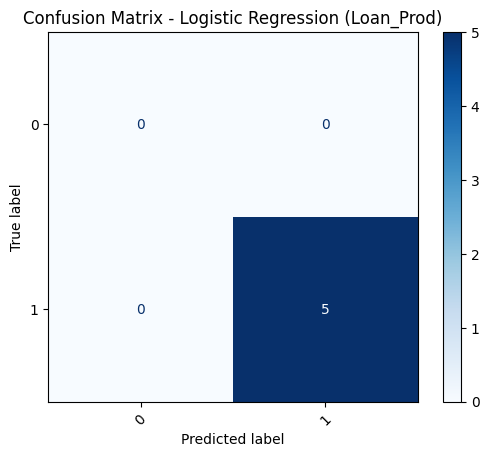

In [60]:
# ===============================
# 5. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression (Loan_Prod)")
plt.show()


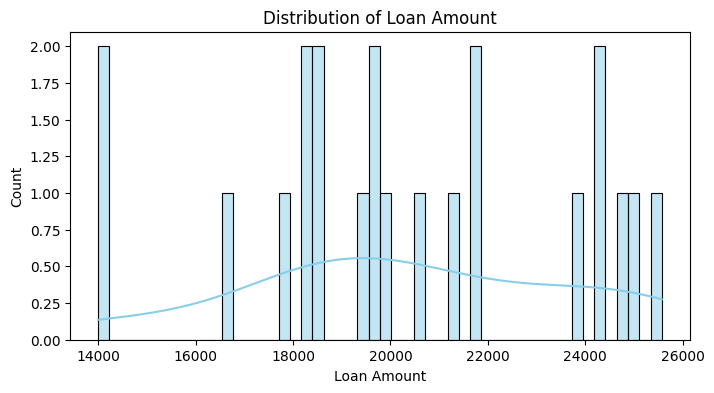

/tmp/ipython-input-4275138447.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="term", y="loanAmount", data=df, palette="Set2")


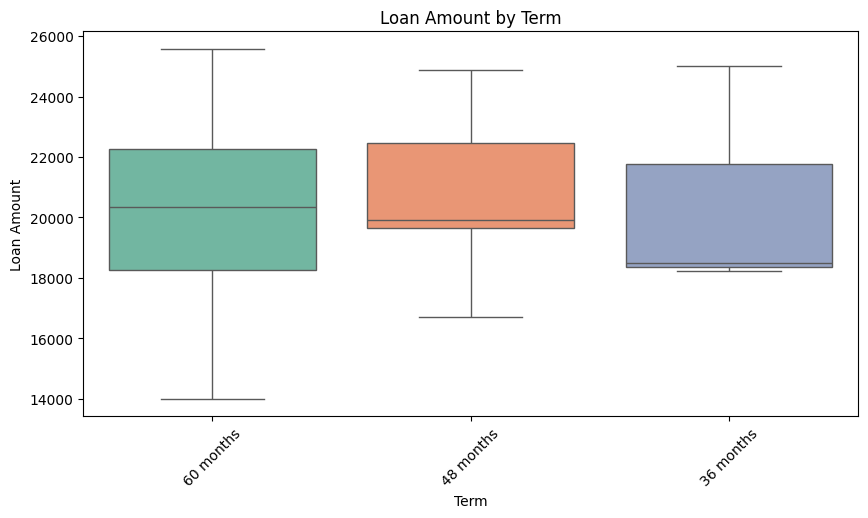

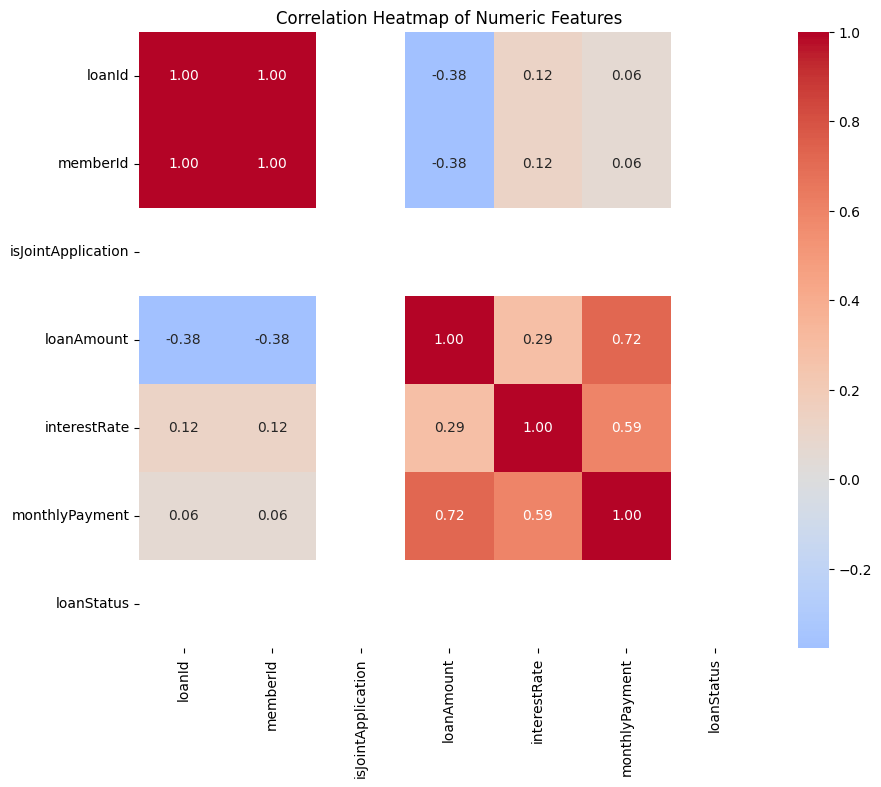

In [62]:
# ===============================
# Loan_Prod.txt – All Visualizations
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataframe
df = loan_prod.copy()

# --- 1. Distribution of Loan Amount ---
plt.figure(figsize=(8,4))
sns.histplot(df["loanAmount"], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

# --- 2. Loan Term vs Loan Amount ---
plt.figure(figsize=(10,5))
sns.boxplot(x="term", y="loanAmount", data=df, palette="Set2")
plt.xticks(rotation=45)
plt.title("Loan Amount by Term")
plt.xlabel("Term")
plt.ylabel("Loan Amount")
plt.show()



# --- 4. Numeric Correlation Heatmap ---
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# --- 5. Loan Amount vs Interest Rate (if column exists) ---
if "intRate" in df.columns:
    plt.figure(figsize=(10,5))
    sns.scatterplot(x="loanAmount", y="intRate", hue="loanStatus", data=df, alpha=0.7)
    plt.title("Loan Amount vs Interest Rate")
    plt.xlabel("Loan Amount")
    plt.ylabel("Interest Rate")
    plt.show()

# --- 6. Sensitive Feature Analysis (example: residentialState) ---
sensitive_feature = "residentialState"
if sensitive_feature in df.columns:
    plt.figure(figsize=(12,5))
    sns.countplot(x=sensitive_feature, hue="loanStatus", data=df, palette="Set3")
    plt.xticks(rotation=45)
    plt.title("Loan Status by Residential State")
    plt.show()
